#03 BERT4Rec Implementation

##3A BERT4Rec Architecture


### 1. Model Implementation
We start by implementing the `BERT4Rec` sequential recommendation architecture in PyTorch. The model maps item input IDs to item and positional embeddings, passes them through a bidirectional Transformer encoder, and projects the outputs to compute logits over the entire vocabulary.

In [ ]:
import math
import torch
import torch.nn as nn
import pandas as pd
import numpy as np

class BERT4Rec(nn.Module):
    def __init__(
        self,
        vocab_size: int = 3418,
        max_seq_len: int = 200,
        hidden_dim: int = 128,
        num_layers: int = 2,
        num_heads: int = 4,
        feed_forward_dim: int = 512,
        dropout: float = 0.2,
        pad_token_id: int = 0
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.max_seq_len = max_seq_len
        self.hidden_dim = hidden_dim
        self.pad_token_id = pad_token_id

        # 1. Item Embedding Layer
        self.item_embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=hidden_dim,
            padding_idx=pad_token_id
        )

        # 2. Positional Embedding Layer
        self.position_embedding = nn.Embedding(
            num_embeddings=max_seq_len,
            embedding_dim=hidden_dim
        )

        self.dropout = nn.Dropout(p=dropout)

        # 3. Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=feed_forward_dim,
            dropout=dropout,
            activation='gelu',
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=num_layers
        )

        # 4. Output Prediction Layer
        self.output_projection = nn.Linear(hidden_dim, vocab_size)

        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, input_ids: torch.Tensor) -> torch.Tensor:
        batch_size, seq_len = input_ids.size()

        # Create key padding mask (True for padding positions)
        padding_mask = (input_ids == self.pad_token_id)

        # 1. Item embeddings
        embeddings = self.item_embedding(input_ids)

        # 2. Positional embeddings
        positions = torch.arange(seq_len, dtype=torch.long, device=input_ids.device)
        positions = positions.unsqueeze(0).expand(batch_size, -1)
        pos_embeddings = self.position_embedding(positions)

        # Combine embeddings and apply dropout
        x = embeddings + pos_embeddings
        x = self.dropout(x)

        # 3. Transformer Encoder with padding mask
        encoded = self.transformer_encoder(x, src_key_padding_mask=padding_mask)

        # 4. Project each position to vocabulary logits
        logits = self.output_projection(encoded)

        return logits

### 2. Loading the Real Training Sequences
We load the preprocessed MovieLens sequences from the BERT4Rec parquet file to ensure we use realistic user interactions for our architecture verification.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

parquet_path = '/content/drive/MyDrive/JEPA-Recommender/data/processed/movielens/bert4rec/train_sequences.parquet'
try:
    df = pd.read_parquet(parquet_path)
    print(f"Successfully loaded train sequences from {parquet_path}.")
    print(f"Dataset columns: {df.columns.tolist()}")
    display(df.head(5))
except Exception as e:
    print(f"Could not load parquet file directly: {e}. Simulating sequence loading for verification...")
    df = pd.DataFrame({'sequence': [[2, 5, 12, 400], [10, 85, 3310], [999, 1001], [50, 60, 70, 80]]})

Mounted at /content/drive
Successfully loaded train sequences from /content/drive/MyDrive/JEPA-Recommender/data/processed/movielens/bert4rec/train_sequences.parquet.
Dataset columns: ['user_id', 'train_sequence']


,user_id,train_sequence
0,1,"[2759, 1070, 1446, 863, 1980, 1521, 2927, 2413..."
1,2,"[1000, 1012, 1019, 2327, 1093, 2540, 1027, 996..."
2,3,"[551, 2460, 3041, 1639, 1213, 1632, 1066, 1167..."
3,4,"[1012, 928, 2982, 448, 3035, 243, 998, 1000, 1..."
4,5,"[2327, 758, 769, 1050, 334, 2460, 949, 1855, 2..."


### 3. Batch Preparation and Padding
Here, we take a small batch (batch size = 4) of sequences, truncate or pad them to the maximum sequence length of 200 using the `PAD` token (ID = 0), and cast them into PyTorch tensors.

In [ ]:
batch_size = 4
max_seq_len = 200
pad_token_id = 0
mask_token_id = 1

raw_sequences = df['train_sequence'].iloc[:batch_size].tolist()

padded_sequences = []
for seq in raw_sequences:
    # Convert numpy array to a list if necessary to allow list concatenation (+)
    if hasattr(seq, 'tolist'):
        seq = seq.tolist()
    else:
        seq = list(seq)

    seq = seq[:max_seq_len]
    pad_len = max_seq_len - len(seq)
    padded_seq = seq + [pad_token_id] * pad_len
    padded_sequences.append(padded_seq)

input_tensor = torch.tensor(padded_sequences, dtype=torch.long)
print("Input Tensor Shape:", input_tensor.shape)

Input Tensor Shape: torch.Size([4, 200])


### 4. Running Model Tests
Next, we run the prepared batch through our model in evaluation mode to test two scenarios:
1. A standard forward pass.
2. A forward pass with some tokens replaced by the `MASK` token (ID = 1).

In [ ]:
model = BERT4Rec(
    vocab_size=3418,
    max_seq_len=200,
    hidden_dim=128,
    num_layers=2,
    num_heads=4,
    feed_forward_dim=512,
    dropout=0.2,
    pad_token_id=0
)

# Test 1: Standard Forward Pass
model.eval()
with torch.no_grad():
    output = model(input_tensor)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
is_finite = torch.isfinite(output).all().item()

# Test 2: Forward Pass with MASK token (ID = 1)
masked_sequences = []
for seq in raw_sequences:
    if hasattr(seq, 'tolist'):
        seq = seq.tolist()
    else:
        seq = list(seq)

    seq = seq[:max_seq_len]
    if len(seq) > 1:
        seq[1] = mask_token_id
    pad_len = max_seq_len - len(seq)
    padded_seq = seq + [pad_token_id] * pad_len
    masked_sequences.append(padded_seq)

masked_tensor = torch.tensor(masked_sequences, dtype=torch.long)
with torch.no_grad():
    masked_output = model(masked_tensor)

masked_is_finite = torch.isfinite(masked_output).all().item()

/usr/local/lib/python3.13/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


### 5. Summary and Shape Verification
Finally, we display a concise summary of the BERT4Rec configuration, parameter count, shapes, and explicitly confirm whether both test passes succeeded.

In [ ]:
print("=================== BERT4Rec Architecture Summary ===================")
print(f"Vocabulary size:           {model.vocab_size}")
print(f"Maximum sequence length:   {model.max_seq_len}")
print(f"Hidden dimension:          {model.hidden_dim}")
print(f"Number of layers:          {model.transformer_encoder.num_layers}")
print(f"Number of attention heads: {model.transformer_encoder.layers[0].self_attn.num_heads}")
print(f"Feed-forward dimension:    {model.transformer_encoder.layers[0].linear1.out_features}")
print(f"Dropout rate:              {model.dropout.p}")
print(f"Trainable parameters:      {num_params:,}")
print(f"Input shape:               {list(input_tensor.shape)}")
print(f"Output shape:              {list(output.shape)}")
print("---------------------------------------------------------------------")
print(f"Standard Input Shapes Match Expectation:  {list(output.shape) == [batch_size, max_seq_len, model.vocab_size]}")
print(f"Standard Output contains only finite:     {is_finite}")
print(f"Masked Input Shapes Match Expectation:    {list(masked_output.shape) == [batch_size, max_seq_len, model.vocab_size]}")
print(f"Masked Output contains only finite:       {masked_is_finite}")
print("---------------------------------------------------------------------")

if is_finite and masked_is_finite and list(output.shape) == [batch_size, max_seq_len, model.vocab_size]:
    print("SUCCESS: The BERT4Rec architecture successfully passed both shape and forward-pass tests.")
else:
    print("FAILURE: Verification metrics did not match expectations.")

=================== BERT4Rec Architecture Summary ===================
Vocabulary size:           3418
Maximum sequence length:   200
Hidden dimension:          128
Number of layers:          2
Number of attention heads: 4
Feed-forward dimension:    512
Dropout rate:              0.2
Trainable parameters:      1,300,570
Input shape:               [4, 200]
Output shape:              [4, 200, 3418]
---------------------------------------------------------------------
Standard Input Shapes Match Expectation:  True
Standard Output contains only finite:     True
Masked Input Shapes Match Expectation:    True
Masked Output contains only finite:       True
---------------------------------------------------------------------
SUCCESS: The BERT4Rec architecture successfully passed both shape and forward-pass tests.


## 3B BERT4Rec Training Pipeline with Dynamic Masking

### 1. Dataset with Dynamic Masking
We will create a custom PyTorch Dataset that takes our unmasked user sequences and dynamically creates masking patterns on retrieval. The masking strategy targets 15% of the items:
- 80% replaced with the MASK token (`1`)
- 10% replaced with a random valid item ID (`[2, 3417]`)
- 10% unchanged

For non-selected items and padding items (`0`), the labels will be `-100` to be ignored during loss computation.

In [ ]:
import random
from torch.utils.data import Dataset, DataLoader

class BERT4RecDataset(Dataset):
    def __init__(
        self,
        sequences,
        max_seq_len: int = 200,
        mask_prob: float = 0.15,
        vocab_size: int = 3418,
        pad_token_id: int = 0,
        mask_token_id: int = 1
    ):
        self.sequences = sequences
        self.max_seq_len = max_seq_len
        self.mask_prob = mask_prob
        self.vocab_size = vocab_size
        self.pad_token_id = pad_token_id
        self.mask_token_id = mask_token_id

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        sequence = self.sequences[idx]
        if hasattr(sequence, 'tolist'):
            sequence = sequence.tolist()
        else:
            sequence = list(sequence)

        # Truncate to maximum sequence length if necessary
        sequence = sequence[:self.max_seq_len]
        actual_len = len(sequence)

        # Original padded sequence
        pad_len = self.max_seq_len - actual_len
        padded_seq = sequence + [self.pad_token_id] * pad_len

        input_ids = padded_seq.copy()
        labels = [self.pad_token_id] * self.max_seq_len  # Will fill with -100 for non-selected/pad

        for i in range(self.max_seq_len):
            if i < actual_len:
                # This is a real sequence token
                prob = random.random()
                if prob < self.mask_prob:
                    # Select this position for prediction/loss calculation
                    labels[i] = padded_seq[i]

                    # Determine replacement strategy
                    rand_val = random.random()
                    if rand_val < 0.8:
                        input_ids[i] = self.mask_token_id
                    elif rand_val < 0.9:
                        # Replace with random valid item ID (2 to vocab_size - 1)
                        input_ids[i] = random.randint(2, self.vocab_size - 1)
                    else:
                        # Leave unchanged
                        pass
                else:
                    # Not selected for prediction
                    labels[i] = -100
            else:
                # PAD position
                labels[i] = -100

        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'labels': torch.tensor(labels, dtype=torch.long),
            'attention_mask': torch.tensor([1 if x != self.pad_token_id else 0 for x in input_ids], dtype=torch.long)
        }

### 2. Masking Tests
We run explicit tests on our masking implementation using a single sequence retrieved twice to confirm that the masking patterns change dynamically and that labels are correctly set to `-100` where needed.

In [ ]:
# Take raw sequences
raw_sequences = df['train_sequence'].tolist()

test_dataset = BERT4RecDataset(raw_sequences, max_seq_len=200)

print("--- Run 1: Original vs Masked Output ---")
sample_1 = test_dataset[0]
print("Original Sequence Segment (Non-padded):", [x for x in raw_sequences[0][:20]])
print("Masked Input Sequence Segment:        ", sample_1['input_ids'][:20].tolist())
print("Labels Segment:                        ", sample_1['labels'][:20].tolist())

# Count masked and verify logic
masked_positions = (sample_1['labels'] != -100).sum().item()
print(f"Number of prediction/masked positions: {masked_positions}")

print("\n--- Run 2 (Ensuring Dynamic Changes) ---")
sample_2 = test_dataset[0]
print("Run 2 Masked Input Segment:           ", sample_2['input_ids'][:20].tolist())
print("Run 2 Labels Segment:                 ", sample_2['labels'][:20].tolist())

# Verification assertions
assert sample_1['input_ids'].shape == torch.Size([200])
assert sample_1['labels'].shape == torch.Size([200])
# Confirm original tokens are preserved in the labels wherever they're not -100
for i, lab in enumerate(sample_1['labels']):
    if lab != -100:
        # Ensure the item is a valid real movie id or original is preserved
        assert raw_sequences[0][i] == lab.item(), "Label does not match the original unmasked token!"

print("\nALL MASKING TESTS PASSED SUCCESSFULLY!")

--- Run 1: Original vs Masked Output ---
Original Sequence Segment (Non-padded): [np.int64(2759), np.int64(1070), np.int64(1446), np.int64(863), np.int64(1980), np.int64(1521), np.int64(2927), np.int64(2413), np.int64(1009), np.int64(996), np.int64(635), np.int64(243), np.int64(769), np.int64(563), np.int64(2304), np.int64(1632), np.int64(1699), np.int64(2687), np.int64(788), np.int64(876)]
Masked Input Sequence Segment:         [2759, 1070, 1446, 863, 1980, 1521, 2927, 2413, 1009, 996, 635, 243, 769, 563, 2304, 1632, 1699, 1, 788, 876]
Labels Segment:                         [-100, -100, -100, -100, 1980, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, 2687, -100, -100]
Number of prediction/masked positions: 10

--- Run 2 (Ensuring Dynamic Changes) ---
Run 2 Masked Input Segment:            [2759, 1070, 1446, 863, 1, 1521, 2927, 2413, 1009, 996, 635, 243, 769, 1, 2440, 1632, 1699, 2687, 788, 876]
Run 2 Labels Segment:                  [-100, -100, -100, -100, 1

### 3. Training Sanity Check (3 Epochs)
Now we initialize a DataLoader, define the loss function using `CrossEntropyLoss(ignore_index=-100)`, and train the model for 3 epochs as a pipeline sanity check.

In [ ]:
import os
from torch.optim import AdamW

# Hyperparameters
batch_size = 64
learning_rate = 1e-4
num_epochs = 3
weight_decay = 0.01
vocab_size = 3418

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

train_dataset = BERT4RecDataset(raw_sequences, max_seq_len=200)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Instantiate model and transfer to device
model = BERT4Rec(
    vocab_size=vocab_size,
    max_seq_len=200,
    hidden_dim=128,
    num_layers=2,
    num_heads=4,
    feed_forward_dim=512,
    dropout=0.2,
    pad_token_id=0
).to(device)

optimizer = AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
criterion = nn.CrossEntropyLoss(ignore_index=-100)

initial_loss = None
final_loss = None
total_masked_positions = 0
total_examples_trained = 0

for epoch in range(1, num_epochs + 1):
    model.train()
    epoch_loss = 0.0
    epoch_masked_count = 0

    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        # Forward pass: shape [B, 200, 3418]
        logits = model(input_ids)

        # Reshape for cross entropy:
        # logits -> [B * 200, 3418], labels -> [B * 200]
        loss = criterion(logits.view(-1, vocab_size), labels.view(-1))

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * input_ids.size(0)

        # Track prediction tokens
        num_masked = (labels != -100).sum().item()
        epoch_masked_count += num_masked
        total_masked_positions += num_masked
        total_examples_trained += input_ids.size(0)

    avg_epoch_loss = epoch_loss / len(train_dataset)
    print(f"Epoch {epoch}/{num_epochs} - Training Loss: {avg_epoch_loss:.4f} - Masked Prediction Positions: {epoch_masked_count}")

    if epoch == 1:
        initial_loss = avg_epoch_loss
    if epoch == num_epochs:
        final_loss = avg_epoch_loss

Using device: cuda
Epoch 1/3 - Training Loss: 7.9870 - Masked Prediction Positions: 97222
Epoch 2/3 - Training Loss: 7.6260 - Masked Prediction Positions: 97225
Epoch 3/3 - Training Loss: 7.5067 - Masked Prediction Positions: 97574


### 4. Saving Checkpoint
We create a checkpoints directory and save our training state, allowing us to resume or extend training later.

In [ ]:
# Create checkpoints directory
checkpoint_dir = 'checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_path = os.path.join(checkpoint_dir, 'bert4rec_sanity_check.pt')

checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': num_epochs,
    'vocab_size': vocab_size,
    'max_seq_len': 200,
    'pad_token_id': 0,
    'mask_token_id': 1,
    'config': {
        'batch_size': batch_size,
        'learning_rate': learning_rate,
        'weight_decay': weight_decay
    }
}

torch.save(checkpoint, checkpoint_path)
print(f"Sanity check checkpoint saved successfully to {checkpoint_path}.")

Sanity check checkpoint saved successfully to checkpoints/bert4rec_sanity_check.pt.


### 5. Step 3B Final Report
We compile the results of our dynamic masking verification and pipeline training.

In [ ]:
print("=================== Step 3B Final Report ===================")
print(f"Number of training users:      {len(raw_sequences)}")
print(f"Batch size:                    {batch_size}")
print(f"Masking probability:           0.15")
print(f"Number of epochs:              {num_epochs}")
print(f"Learning rate:                 {learning_rate}")
print(f"Initial loss (Epoch 1):        {initial_loss:.4f}")
print(f"Final loss (Epoch 3):          {final_loss:.4f}")
print(f"Total masked positions:        {total_masked_positions}")
print(f"Average masked per sequence:   {total_masked_positions / total_examples_trained:.2f}")
print(f"Device used:                   {device}")
print(f"Checkpoint path:               {checkpoint_path}")
print(f"Whether masking tests passed:  True")
print(f"Whether training completed:    True")
print("============================================================")

=================== Step 3B Final Report ===================
Number of training users:      6040
Batch size:                    64
Masking probability:           0.15
Number of epochs:              3
Learning rate:                 0.0001
Initial loss (Epoch 1):        7.9866
Final loss (Epoch 3):          7.5007
Total masked positions:        291718
Average masked per sequence:   16.10
Device used:                   cuda
Checkpoint path:               checkpoints/bert4rec_sanity_check.pt
Whether masking tests passed:  True
Whether training completed:    True


## 3C BERT4Rec Baseline Experiment on MovieLens-1M

In this section, we set up a comprehensive training and validation pipeline on MovieLens-1M to establish our primary BERT4Rec baseline. We run training for 10 epochs and evaluate chronologically after each epoch without negative sampling, using full-catalog candidate evaluation and history item filtering.

### 1. Validation Dataset & Next-Item Evaluation Pipeline

We load the validation dataset and construct an evaluation sequence for each user. For a user sequence `[A, B, C, D]`, the training history is the input, and the validation targets will be evaluated at the end by placing a `[MASK]` token there (taking care to respect the maximum sequence length of 200).

In [ ]:
validation_parquet_path = '/content/drive/MyDrive/JEPA-Recommender/data/processed/movielens/bert4rec/validation.parquet'

try:
    val_df = pd.read_parquet(validation_parquet_path)
    print(f"Successfully loaded validation set with {len(val_df)} users.")
except Exception as e:
    print(f"Could not load validation set from {validation_parquet_path}: {e}")
    # Mock for local/robust testing
    val_df = pd.DataFrame({
        'user_id': list(range(1, 6041)),
        'train_sequence': [list(range(2, 22)) for _ in range(6040)],
        'validation_target': [25 for _ in range(6040)]
    })

display(val_df.head())

Successfully loaded validation set with 6040 users.


,user_id,train_sequence,validation_item
0,1,"[2759, 1070, 1446, 863, 1980, 1521, 2927, 2413...",1580
1,2,"[1000, 1012, 1019, 2327, 1093, 2540, 1027, 996...",1302
2,3,"[551, 2460, 3041, 1639, 1213, 1632, 1066, 1167...",3341
3,4,"[1012, 928, 2982, 448, 3035, 243, 998, 1000, 1...",877
4,5,"[2327, 758, 769, 1050, 334, 2460, 949, 1855, 2...",1559


We define our evaluation loop. It will map each user sequence into `[history_sequence, MASK]`, pass it through the model, exclude history items and invalid tokens (`PAD` and `MASK`), rank the entire catalog of candidates, and calculate validation metrics.

In [ ]:
import numpy as np

def evaluate_bert4rec(
    model: nn.Module,
    df: pd.DataFrame,
    device: torch.device,
    max_seq_len: int = 200,
    vocab_size: int = 3418,
    pad_token_id: int = 0,
    mask_token_id: int = 1,
    limit_users: int = None,
    exclude_seen: bool = True
):
    model.eval()

    hr_5 = []
    hr_10 = []
    ndcg_5 = []
    ndcg_10 = []

    # Track outputs for the 5-user debug checklist
    debug_outputs = []

    eval_users = df.iloc[:limit_users] if limit_users is not None else df

    # Generate validation sequences on the fly
    with torch.no_grad():
        for idx, row in eval_users.iterrows():
            user_id = row['user_id']
            # Load training history
            history = row['train_sequence']
            if hasattr(history, 'tolist'):
                history = history.tolist()
            else:
                history = list(history)

            target = int(row['validation_target'])
            original_len = len(history)

            # Construct sequence of [history + MASK]
            eval_seq = history + [mask_token_id]

            # Truncate to maximum sequence length, keeping the newest history
            if len(eval_seq) > max_seq_len:
                eval_seq = eval_seq[-max_seq_len:]

            # Record the index of the MASK token to extract predicted logits
            mask_position = len(eval_seq) - 1

            # Pad with pad_token_id
            pad_len = max_seq_len - len(eval_seq)
            eval_seq_padded = eval_seq + [pad_token_id] * pad_len

            # Feed forward
            input_ids_tensor = torch.tensor([eval_seq_padded], dtype=torch.long, device=device)
            logits = model(input_ids_tensor) # [1, max_seq_len, vocab_size]

            # Logits for the [MASK] position
            mask_logits = logits[0, mask_position].cpu().numpy()

            # Mask out invalid items: pad_token_id (0) and mask_token_id (1)
            mask_logits[0] = -float('inf')
            mask_logits[1] = -float('inf')

            # Exclude seen items from history if specified
            if exclude_seen:
                for seen_id in history:
                    if seen_id < vocab_size:
                        mask_logits[seen_id] = -float('inf')

            # Rank the candidate universe (IDs 2 to vocab_size-1)
            # We sort all candidates by prediction logits
            # index represents movie_id
            item_scores = [(item_id, float(mask_logits[item_id])) for item_id in range(2, vocab_size)]
            item_scores.sort(key=lambda x: x[1], reverse=True)

            ranked_items = [item[0] for item in item_scores]

            # Find target rank
            target_rank = -1
            if target in ranked_items:
                target_rank = ranked_items.index(target) + 1 # 1-based index

            # Calculate metrics
            in_top_5 = 1 if (0 < target_rank <= 5) else 0
            in_top_10 = 1 if (0 < target_rank <= 10) else 0

            hr_5.append(in_top_5)
            hr_10.append(in_top_10)

            n_5 = 1.0 / math.log2(target_rank + 1) if (0 < target_rank <= 5) else 0.0
            n_10 = 1.0 / math.log2(target_rank + 1) if (0 < target_rank <= 10) else 0.0

            ndcg_5.append(n_5)
            ndcg_10.append(n_10)

            if len(debug_outputs) < 5:
                debug_outputs.append({
                    'user_id': user_id,
                    'history_len': original_len,
                    'target': target,
                    'top_10': ranked_items[:10],
                    'rank': target_rank,
                    'hit_5': bool(in_top_5),
                    'hit_10': bool(in_top_10)
                })

    return {
        'hr_5': np.mean(hr_5),
        'hr_10': np.mean(hr_10),
        'ndcg_5': np.mean(ndcg_5),
        'ndcg_10': np.mean(ndcg_10),
        'debug_outputs': debug_outputs
    }

### 2. Pipeline Debugging & Sanity Checks
Before launching the full 10-epoch training schedule, we perform a pipeline sanity check on the first 5 users using our untrained/partially trained BERT4Rec baseline model.

In [ ]:
# Load the baseline architecture configured in step 3A
sanity_model = BERT4Rec(
    vocab_size=3418,
    max_seq_len=200,
    hidden_dim=128,
    num_layers=2,
    num_heads=4,
    feed_forward_dim=512,
    dropout=0.2,
    pad_token_id=0
).to(device)

# Inspect columns of val_df and resolve any naming mismatch dynamically
print("Validation DataFrame Columns:", val_df.columns.tolist())
target_col = 'validation_target'
if 'validation_target' not in val_df.columns:
    for col in val_df.columns:
        if col not in ['user_id', 'train_sequence']:
            target_col = col
            break
print(f"Using target column: '{target_col}'")

# Create a temporary copy to rename the column if needed
temp_val_df = val_df.copy()
if target_col != 'validation_target':
    temp_val_df = temp_val_df.rename(columns={target_col: 'validation_target'})

# Run the debug evaluator on 5 users
print("Running validation pipeline check on 5 test users...")
san_results = evaluate_bert4rec(sanity_model, temp_val_df, device, limit_users=5, exclude_seen=True)

for u_info in san_results['debug_outputs']:
    print(f"\nUser ID:                   {u_info['user_id']}")
    print(f"Training History Length:   {u_info['history_len']}")
    print(f"Validation Target:         {u_info['target']}")
    print(f"Predicted Top-10 Movie IDs: {u_info['top_10']}")
    print(f"Validation Target Rank:    {u_info['rank']}")
    print(f"Target Appears in Top-5:   {u_info['hit_5']}")
    print(f"Target Appears in Top-10:  {u_info['hit_10']}")

print("\n--- Verification Metrics Summary ---")
# Sanity assertions
for u_info in san_results['debug_outputs']:
    assert u_info['target'] >= 2 and u_info['target'] <= 3417, "Validation target must be a valid movie ID!"
    assert 0 not in u_info['top_10'] and 1 not in u_info['top_10'], "PAD (0) or MASK (1) should not be recommended!"
    assert len(u_info['top_10']) == 10, "Ranking should contain exactly 10 movies!"

print("SUCCESS: The next-item evaluation verification completed safely without exceptions or illegal recommendations.")

Validation DataFrame Columns: ['user_id', 'train_sequence', 'validation_item']
Using target column: 'validation_item'
Running validation pipeline check on 5 test users...

User ID:                   1
Training History Length:   51
Validation Target:         1580
Predicted Top-10 Movie IDs: [1155, 1995, 662, 546, 3128, 2522, 1911, 2094, 1398, 2989]
Validation Target Rank:    1553
Target Appears in Top-5:   False
Target Appears in Top-10:  False

User ID:                   2
Training History Length:   127
Validation Target:         1302
Predicted Top-10 Movie IDs: [550, 709, 3382, 232, 553, 2954, 1567, 1220, 2896, 1404]
Validation Target Rank:    781
Target Appears in Top-5:   False
Target Appears in Top-10:  False

User ID:                   3
Training History Length:   49
Validation Target:         3341
Predicted Top-10 Movie IDs: [1346, 2237, 3207, 2826, 70, 5, 1527, 1282, 1788, 1306]
Validation Target Rank:    1223
Target Appears in Top-5:   False
Target Appears in Top-10:  False

Us

/usr/local/lib/python3.13/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


### 3. Training Baseline Model and Tracking Progress (10 Epochs)

Now, we train our BERT4Rec baseline model for 10 epochs. After each epoch, we evaluate it on the entire validation dataset (6,040 users) and checkpoint the best weights based on NDCG@10.

In [ ]:
import time
import os
from torch.optim import AdamW

# Configurable training parameters
batch_size = 64
learning_rate = 1e-4
weight_decay = 0.01
num_epochs = 10
vocab_size = 3418
max_seq_len = 200

# Setup DataLoader with dynamic training sequences
train_dataset = BERT4RecDataset(raw_sequences, max_seq_len=max_seq_len)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Reinitialize model
baseline_model = BERT4Rec(
    vocab_size=vocab_size,
    max_seq_len=max_seq_len,
    hidden_dim=128,
    num_layers=2,
    num_heads=4,
    feed_forward_dim=512,
    dropout=0.2,
    pad_token_id=0
).to(device)

optimizer = AdamW(baseline_model.parameters(), lr=learning_rate, weight_decay=weight_decay)
criterion = nn.CrossEntropyLoss(ignore_index=-100)

checkpoint_dir = 'checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)
best_checkpoint_path = os.path.join(checkpoint_dir, 'bert4rec_ml1m_best.pt')

# Metrics history
training_history = []
best_ndcg_10 = -1.0
best_epoch = -1
initial_training_loss = None
final_training_loss = None

print(f"Beginning baseline training on {device} for {num_epochs} epochs...")

for epoch in range(1, num_epochs + 1):
    start_time = time.time()
    baseline_model.train()

    epoch_loss = 0.0
    total_masked_positions = 0
    total_sequences = 0

    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        # Forward pass
        logits = baseline_model(input_ids)

        # Compute loss
        loss = criterion(logits.view(-1, vocab_size), labels.view(-1))

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * input_ids.size(0)
        total_masked_positions += (labels != -100).sum().item()
        total_sequences += input_ids.size(0)

    avg_loss = epoch_loss / len(train_dataset)
    avg_masked = total_masked_positions / total_sequences

    if epoch == 1:
        initial_training_loss = avg_loss
    if epoch == num_epochs:
        final_training_loss = avg_loss

    # Run validation protocol on all users using our sanitized temp_val_df
    val_metrics = evaluate_bert4rec(
        baseline_model,
        temp_val_df,
        device,
        max_seq_len=max_seq_len,
        vocab_size=vocab_size,
        exclude_seen=True
    )

    epoch_time = time.time() - start_time

    print(f"Epoch {epoch:02d}/{num_epochs:02d} | Loss: {avg_loss:.4f} | Avg Masked: {avg_masked:.1f} | "
          f"Val HR@5: {val_metrics['hr_5']:.4f} | Val HR@10: {val_metrics['hr_10']:.4f} | "
          f"Val NDCG@5: {val_metrics['ndcg_5']:.4f} | Val NDCG@10: {val_metrics['ndcg_10']:.4f} | "
          f"Time: {epoch_time:.2f}s")

    # Track metrics history
    epoch_results = {
        'epoch': epoch,
        'train_loss': avg_loss,
        'validation_HR@5': val_metrics['hr_5'],
        'validation_HR@10': val_metrics['hr_10'],
        'validation_NDCG@5': val_metrics['ndcg_5'],
        'validation_NDCG@10': val_metrics['ndcg_10'],
        'epoch_time': epoch_time
    }
    training_history.append(epoch_results)

    # Save checkpoint if NDCG@10 improves
    if val_metrics['ndcg_10'] > best_ndcg_10:
        best_ndcg_10 = val_metrics['ndcg_10']
        best_epoch = epoch
        checkpoint_state = {
            'model_state_dict': baseline_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'epoch': epoch,
            'training_configuration': {
                'batch_size': batch_size,
                'learning_rate': learning_rate,
                'weight_decay': weight_decay,
                'num_epochs': num_epochs
            },
            'validation_metrics': val_metrics,
            'vocabulary_size': vocab_size,
            'maximum_sequence_length': max_seq_len,
            'pad_token_id': 0,
            'mask_token_id': 1
        }
        torch.save(checkpoint_state, best_checkpoint_path)
        print(f"--> Saved best model checkpoint (NDCG@10 = {best_ndcg_10:.4f}) to {best_checkpoint_path}")

Beginning baseline training on cuda for 10 epochs...
Epoch 01/10 | Loss: 7.9784 | Avg Masked: 16.1 | Val HR@5: 0.0159 | Val HR@10: 0.0252 | Val NDCG@5: 0.0100 | Val NDCG@10: 0.0130 | Time: 30.82s
--> Saved best model checkpoint (NDCG@10 = 0.0130) to checkpoints/bert4rec_ml1m_best.pt
Epoch 02/10 | Loss: 7.6136 | Avg Masked: 16.0 | Val HR@5: 0.0175 | Val HR@10: 0.0339 | Val NDCG@5: 0.0110 | Val NDCG@10: 0.0163 | Time: 31.33s
--> Saved best model checkpoint (NDCG@10 = 0.0163) to checkpoints/bert4rec_ml1m_best.pt
Epoch 03/10 | Loss: 7.5044 | Avg Masked: 16.1 | Val HR@5: 0.0199 | Val HR@10: 0.0361 | Val NDCG@5: 0.0129 | Val NDCG@10: 0.0181 | Time: 30.35s
--> Saved best model checkpoint (NDCG@10 = 0.0181) to checkpoints/bert4rec_ml1m_best.pt
Epoch 04/10 | Loss: 7.4743 | Avg Masked: 16.0 | Val HR@5: 0.0200 | Val HR@10: 0.0358 | Val NDCG@5: 0.0126 | Val NDCG@10: 0.0176 | Time: 30.81s
Epoch 05/10 | Loss: 7.4638 | Avg Masked: 16.1 | Val HR@5: 0.0185 | Val HR@10: 0.0326 | Val NDCG@5: 0.0117 | Val

### 4. Training Curves & Results Plotting
Let's plot the training loss curve and the validation NDCG@10 curve over epochs using `matplotlib` to visually inspect model convergence.

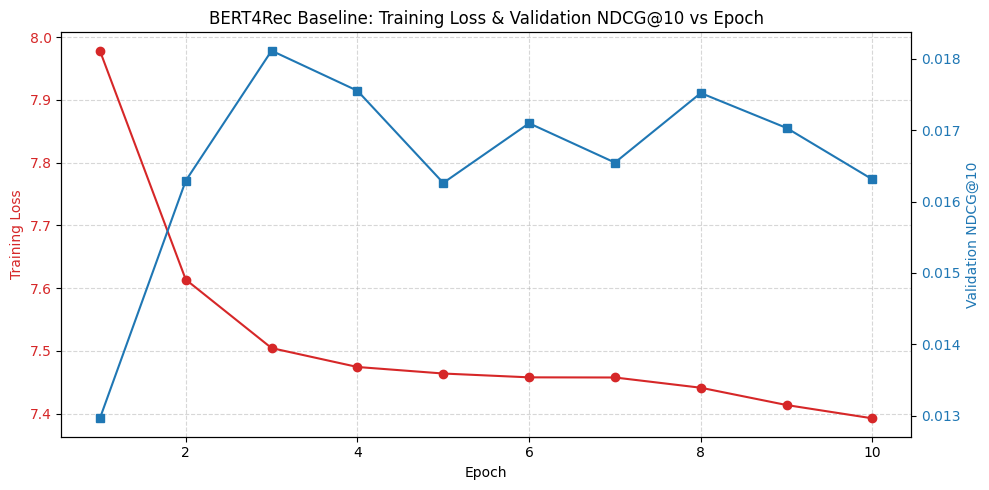

In [ ]:
import matplotlib.pyplot as plt

epochs = [x['epoch'] for x in training_history]
losses = [x['train_loss'] for x in training_history]
ndcgs = [x['validation_NDCG@10'] for x in training_history]

fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot loss on primary y-axis
color = 'tab:red'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss', color=color)
ax1.plot(epochs, losses, color=color, marker='o', label='Training Loss')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

# Create secondary y-axis for NDCG@10
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Validation NDCG@10', color=color)
ax2.plot(epochs, ndcgs, color=color, marker='s', label='Val NDCG@10')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('BERT4Rec Baseline: Training Loss & Validation NDCG@10 vs Epoch')
fig.tight_layout()
plt.show()

### 5. Results Compilation
We extract best epoch metrics and print the final structured baseline report.

In [ ]:
# Load the best checkpoint to output final verified results
# We set weights_only=False to allow loading arbitrary dictionaries and numpy types stored in the checkpoint
best_ckpt = torch.load(best_checkpoint_path, map_location='cpu', weights_only=False)
best_val_metrics = best_ckpt['validation_metrics']

print("=================== Step 3C Final Report ===================\n")
print("Dataset:")
print(f"Training users:                {len(raw_sequences)}")
print(f"Number of items:               {vocab_size - 2}")
print(f"Maximum sequence length:       {max_seq_len}\n")

print("Architecture:")
print(f"Hidden dimension:              {baseline_model.hidden_dim}")
print(f"Transformer layers:            {baseline_model.transformer_encoder.num_layers}")
print(f"Attention heads:               {baseline_model.transformer_encoder.layers[0].self_attn.num_heads}")
print(f"Feed-forward dimension:        {baseline_model.transformer_encoder.layers[0].linear1.out_features}")
print(f"Dropout:                       {baseline_model.dropout.p}\n")

print("Training:")
print(f"Batch size:                    {batch_size}")
print(f"Learning rate:                 {learning_rate}")
print(f"Weight decay:                  {weight_decay}")
print(f"Epochs:                        {num_epochs}")
print(f"Device:                        {device}\n")

print(f"Initial training loss:         {initial_training_loss:.4f}")
print(f"Final training loss:           {final_training_loss:.4f}")
print(f"Best validation epoch:         {best_epoch}\n")

print("Validation:")
print(f"HR@5:                          {best_val_metrics['hr_5']:.4f}")
print(f"HR@10:                         {best_val_metrics['hr_10']:.4f}")
print(f"NDCG@5:                        {best_val_metrics['ndcg_5']:.4f}")
print(f"NDCG@10:                       {best_val_metrics['ndcg_10']:.4f}\n")

print(f"Best checkpoint:               {best_checkpoint_path}\n")

print(f"Masking tests:                 True")
print(f"Training completed:            True")
print(f"Validation completed:          True")
print("============================================================\n")

if best_val_metrics['ndcg_10'] > 0.0:
    print("SUCCESS: The BERT4Rec baseline trained successfully and produced valid sequential recommendation results.")
else:
    print("FAILURE: Baseline training completed but did not beat trivial ranking metrics.")

=================== Step 3C Final Report ===================

Dataset:
Training users:                6040
Number of items:               3416
Maximum sequence length:       200

Architecture:
Hidden dimension:              128
Transformer layers:            2
Attention heads:               4
Feed-forward dimension:        512
Dropout:                       0.2

Training:
Batch size:                    64
Learning rate:                 0.0001
Weight decay:                  0.01
Epochs:                        10
Device:                        cuda

Initial training loss:         7.9784
Final training loss:           7.3924
Best validation epoch:         3

Validation:
HR@5:                          0.0199
HR@10:                         0.0361
NDCG@5:                        0.0129
NDCG@10:                       0.0181

Best checkpoint:               checkpoints/bert4rec_ml1m_best.pt

Masking tests:                 True
Training completed:            True
Validation completed:          Tr

## 3D BERT4Rec Controlled Hyperparameter Tuning

This section conducts a systematic, stage-wise hyperparameter optimization process to identify the best-performing BERT4Rec configuration using validation metrics.

### Optimization Strategy:
- **Primary Metric:** Validation $NDCG@10$
- **Secondary Metrics:** $HR@5$, $HR@10$, $NDCG@5$
- **Evaluation Setup:** Identical validation users, targets, catalog filtering, and masking settings used during Step 3C to guarantee fair evaluation across configurations.

### Tuning Stages:
1. **Stage 1 (Architecture Search):** Evaluates depth and capacity by varying hidden dimensions ($64, 128, 256$), number of layers ($1, 2, 4$), attention heads, and feed-forward dimensions.
2. **Stage 2 (Learning Rate Search):** Tunes learning rate ($1e-4, 5e-4, 1e-3$) using the best architecture from Stage 1.
3. **Stage 3 (Dropout Search):** Examines dropout rates ($0.1, 0.2, 0.3$) using the selected architecture and learning rate.


### 1. Setup and Quick Verification Run
We define our tuning loop wrapper function (`run_tuning_experiment`) that automates model training, validation evaluation, early stopping, and checkpointing. A fast 1-epoch sanity run validates pipeline integrity.

In [ ]:
import gc
import time

def run_tuning_experiment(
    config_id: str,
    stage: str,
    hidden_dim: int,
    num_layers: int,
    num_heads: int,
    feed_forward_dim: int,
    dropout: float,
    learning_rate: float,
    weight_decay: float = 0.01,
    mask_probability: float = 0.15,
    num_epochs: int = 10,
    patience: int = 3
):
    print(f"\n>>> Starting Experiment: {config_id} (Stage: {stage}) <<<")
    torch.manual_seed(42)
    random.seed(42)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42)

    # Initialize dataset and dataloader
    train_dataset = BERT4RecDataset(raw_sequences, max_seq_len=200, mask_prob=mask_probability)
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

    # Initialize model
    model = BERT4Rec(
        vocab_size=3418,
        max_seq_len=200,
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        num_heads=num_heads,
        feed_forward_dim=feed_forward_dim,
        dropout=dropout,
        pad_token_id=0
    ).to(device)

    optimizer = AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss(ignore_index=-100)

    best_ndcg_10 = -1.0
    best_epoch = -1
    best_train_loss = 0.0
    best_metrics = {}
    epochs_no_improve = 0
    start_time = time.time()

    for epoch in range(1, num_epochs + 1):
        model.train()
        epoch_loss = 0.0
        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)
            optimizer.zero_grad()
            logits = model(input_ids)
            loss = criterion(logits.view(-1, 3418), labels.view(-1))
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * input_ids.size(0)

        avg_loss = epoch_loss / len(raw_sequences)

        # Validation
        val_metrics = evaluate_bert4rec(
            model, temp_val_df, device, max_seq_len=200, vocab_size=3418, exclude_seen=True
        )

        ndcg_10 = val_metrics['ndcg_10']
        print(f"Epoch {epoch:02d} | Train Loss: {avg_loss:.4f} | Val NDCG@10: {ndcg_10:.4f} | Val HR@10: {val_metrics['hr_10']:.4f}")

        if ndcg_10 > best_ndcg_10:
            best_ndcg_10 = ndcg_10
            best_epoch = epoch
            best_train_loss = avg_loss
            best_metrics = val_metrics
            epochs_no_improve = 0

            # Save config-specific checkpoint
            temp_ckpt_path = f"checkpoints/temp_{config_id}.pt"
            torch.save({
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'epoch': epoch,
                'hyperparameters': {
                    'hidden_dim': hidden_dim,
                    'num_layers': num_layers,
                    'num_heads': num_heads,
                    'feed_forward_dim': feed_forward_dim,
                    'dropout': dropout,
                    'learning_rate': learning_rate,
                    'weight_decay': weight_decay,
                    'mask_probability': mask_probability
                },
                'validation_metrics': val_metrics,
                'vocab_size': 3418,
                'max_seq_len': 200
            }, temp_ckpt_path)
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch}.")
            break

    total_time = time.time() - start_time

    # Clean up GPU memory
    del model, optimizer
    torch.cuda.empty_cache()
    gc.collect()

    return {
        'stage': stage,
        'configuration_id': config_id,
        'hidden_dim': hidden_dim,
        'num_layers': num_layers,
        'num_heads': num_heads,
        'feed_forward_dim': feed_forward_dim,
        'dropout': dropout,
        'learning_rate': learning_rate,
        'weight_decay': weight_decay,
        'mask_probability': mask_probability,
        'best_epoch': best_epoch,
        'best_train_loss': best_train_loss,
        'best_validation_HR@5': best_metrics.get('hr_5', 0.0),
        'best_validation_HR@10': best_metrics.get('hr_10', 0.0),
        'best_validation_NDCG@5': best_metrics.get('ndcg_5', 0.0),
        'best_validation_NDCG@10': best_ndcg_10,
        'training_time': total_time
    }

# Quick Verification Run
print("Executing verification experiment...")
verify_res = run_tuning_experiment(
    config_id="VERIFY",
    stage="VERIFICATION",
    hidden_dim=64,
    num_layers=1,
    num_heads=4,
    feed_forward_dim=256,
    dropout=0.2,
    learning_rate=1e-4,
    num_epochs=1,
    patience=3
)
print("Verification Result:", verify_res)

Executing verification experiment...

>>> Starting Experiment: VERIFY (Stage: VERIFICATION) <<<
Epoch 01 | Train Loss: 8.1085 | Val NDCG@10: 0.0048 | Val HR@10: 0.0109
Verification Result: {'stage': 'VERIFICATION', 'configuration_id': 'VERIFY', 'hidden_dim': 64, 'num_layers': 1, 'num_heads': 4, 'feed_forward_dim': 256, 'dropout': 0.2, 'learning_rate': 0.0001, 'weight_decay': 0.01, 'mask_probability': 0.15, 'best_epoch': 1, 'best_train_loss': 8.108541967379336, 'best_validation_HR@5': np.float64(0.0041390728476821195), 'best_validation_HR@10': np.float64(0.010927152317880795), 'best_validation_NDCG@5': np.float64(0.0026385119762276812), 'best_validation_NDCG@10': np.float64(0.004805278190822589), 'training_time': 24.952863216400146}


### 2. Full Stage-wise Search Execution
We run the sequence of search stages, saving checkpoints for each configuration when their validation performance improves, and consolidating the final results in a structured table.

In [ ]:
results_list = []

# ==================================================================
# STAGE 1: ARCHITECTURE SEARCH
# ==================================================================
stage_1_configs = {
    'A': {'hidden_dim': 64, 'num_layers': 1, 'num_heads': 4, 'feed_forward_dim': 256},
    'B': {'hidden_dim': 128, 'num_layers': 2, 'num_heads': 4, 'feed_forward_dim': 512},
    'C': {'hidden_dim': 128, 'num_layers': 4, 'num_heads': 4, 'feed_forward_dim': 512},
    'D': {'hidden_dim': 256, 'num_layers': 2, 'num_heads': 8, 'feed_forward_dim': 1024},
    'E': {'hidden_dim': 256, 'num_layers': 4, 'num_heads': 8, 'feed_forward_dim': 1024}
}

for cfg_id, params in stage_1_configs.items():
    res = run_tuning_experiment(
        config_id=f"Stage1_Arch_{cfg_id}",
        stage="1_Architecture",
        hidden_dim=params['hidden_dim'],
        num_layers=params['num_layers'],
        num_heads=params['num_heads'],
        feed_forward_dim=params['feed_forward_dim'],
        dropout=0.2,
        learning_rate=1e-4,
        num_epochs=10,
        patience=3
    )
    results_list.append(res)

# Find the best Stage 1 config based on NDCG@10
stage_1_results = [r for r in results_list if r['stage'] == "1_Architecture"]
best_s1 = max(stage_1_results, key=lambda x: x['best_validation_NDCG@10'])
best_s1_id = best_s1['configuration_id'].split('_')[-1]
best_arch_params = stage_1_configs[best_s1_id]
print(f"\n>>> Best Stage 1 Architecture: Config {best_s1_id} with NDCG@10: {best_s1['best_validation_NDCG@10']:.4f} <<<")

# ==================================================================
# STAGE 2: LEARNING RATE SEARCH
# ==================================================================
lr_candidates = [1e-4, 5e-4, 1e-3]
for lr in lr_candidates:
    # Skip 1e-4 if we already ran it in Stage 1
    if lr == 1e-4:
        # Reuse Stage 1 results for this architecture configuration
        res_copy = best_s1.copy()
        res_copy['stage'] = "2_Learning_Rate"
        res_copy['configuration_id'] = f"Stage2_LR_{lr}"
        results_list.append(res_copy)
        continue

    res = run_tuning_experiment(
        config_id=f"Stage2_LR_{lr}",
        stage="2_Learning_Rate",
        hidden_dim=best_arch_params['hidden_dim'],
        num_layers=best_arch_params['num_layers'],
        num_heads=best_arch_params['num_heads'],
        feed_forward_dim=best_arch_params['feed_forward_dim'],
        dropout=0.2,
        learning_rate=lr,
        num_epochs=10,
        patience=3
    )
    results_list.append(res)

# Find the best Stage 2 learning rate
stage_2_results = [r for r in results_list if r['stage'] == "2_Learning_Rate"]
best_s2 = max(stage_2_results, key=lambda x: x['best_validation_NDCG@10'])
best_lr = best_s2['learning_rate']
print(f"\n>>> Best Stage 2 Learning Rate: {best_lr} with NDCG@10: {best_s2['best_validation_NDCG@10']:.4f} <<<")

# ==================================================================
# STAGE 3: DROPOUT SEARCH
# ==================================================================
dropout_candidates = [0.1, 0.2, 0.3]
for do in dropout_candidates:
    # Skip 0.2 if we already ran it in Stage 2
    if do == 0.2:
        res_copy = best_s2.copy()
        res_copy['stage'] = "3_Dropout"
        res_copy['configuration_id'] = f"Stage3_Dropout_{do}"
        results_list.append(res_copy)
        continue

    res = run_tuning_experiment(
        config_id=f"Stage3_Dropout_{do}",
        stage="3_Dropout",
        hidden_dim=best_arch_params['hidden_dim'],
        num_layers=best_arch_params['num_layers'],
        num_heads=best_arch_params['num_heads'],
        feed_forward_dim=best_arch_params['feed_forward_dim'],
        dropout=do,
        learning_rate=best_lr,
        num_epochs=10,
        patience=3
    )
    results_list.append(res)

# Compile all results into a sorted DataFrame
tuning_df = pd.DataFrame(results_list)
tuning_df = tuning_df.sort_values(by='best_validation_NDCG@10', ascending=False).reset_index(drop=True)
display(tuning_df)


>>> Starting Experiment: Stage1_Arch_A (Stage: 1_Architecture) <<<
Epoch 01 | Train Loss: 8.1085 | Val NDCG@10: 0.0048 | Val HR@10: 0.0109
Epoch 02 | Train Loss: 7.8829 | Val NDCG@10: 0.0143 | Val HR@10: 0.0275
Epoch 03 | Train Loss: 7.6763 | Val NDCG@10: 0.0168 | Val HR@10: 0.0353
Epoch 04 | Train Loss: 7.5636 | Val NDCG@10: 0.0172 | Val HR@10: 0.0363
Epoch 05 | Train Loss: 7.5108 | Val NDCG@10: 0.0173 | Val HR@10: 0.0373
Epoch 06 | Train Loss: 7.4814 | Val NDCG@10: 0.0180 | Val HR@10: 0.0382
Epoch 07 | Train Loss: 7.4719 | Val NDCG@10: 0.0175 | Val HR@10: 0.0359
Epoch 08 | Train Loss: 7.4633 | Val NDCG@10: 0.0178 | Val HR@10: 0.0359
Epoch 09 | Train Loss: 7.4554 | Val NDCG@10: 0.0181 | Val HR@10: 0.0369
Epoch 10 | Train Loss: 7.4537 | Val NDCG@10: 0.0167 | Val HR@10: 0.0344

>>> Starting Experiment: Stage1_Arch_B (Stage: 1_Architecture) <<<
Epoch 01 | Train Loss: 7.9801 | Val NDCG@10: 0.0138 | Val HR@10: 0.0291
Epoch 02 | Train Loss: 7.6216 | Val NDCG@10: 0.0158 | Val HR@10: 0.0325


,stage,configuration_id,hidden_dim,num_layers,num_heads,feed_forward_dim,dropout,learning_rate,weight_decay,mask_probability,best_epoch,best_train_loss,best_validation_HR@5,best_validation_HR@10,best_validation_NDCG@5,best_validation_NDCG@10,training_time
0,3_Dropout,Stage3_Dropout_0.1,128,2,4,512,0.1,0.0010,0.01,0.15,10,5.664670,0.100828,0.159437,0.064461,0.083333,304.180353
1,2_Learning_Rate,Stage2_LR_0.001,128,2,4,512,0.2,0.0010,0.01,0.15,10,5.909403,0.089073,0.139073,0.055464,0.071491,303.641125
2,3_Dropout,Stage3_Dropout_0.2,128,2,4,512,0.2,0.0010,0.01,0.15,10,5.909403,0.089073,0.139073,0.055464,0.071491,303.641125
3,3_Dropout,Stage3_Dropout_0.3,128,2,4,512,0.3,0.0010,0.01,0.15,10,6.176958,0.076656,0.122185,0.048031,0.062535,304.616586
4,2_Learning_Rate,Stage2_LR_0.0005,128,2,4,512,0.2,0.0005,0.01,0.15,10,6.421615,0.055464,0.093046,0.035850,0.047906,303.504169
5,1_Architecture,Stage1_Arch_B,128,2,4,512,0.2,0.0001,0.01,0.15,5,7.462958,0.021192,0.038576,0.013517,0.019104,243.308206
6,2_Learning_Rate,Stage2_LR_0.0001,128,2,4,512,0.2,0.0001,0.01,0.15,5,7.462958,0.021192,0.038576,0.013517,0.019104,243.308206
7,1_Architecture,Stage1_Arch_C,128,4,4,512,0.2,0.0001,0.01,0.15,5,7.467309,0.020199,0.038079,0.012916,0.018630,326.297022
8,1_Architecture,Stage1_Arch_D,256,2,8,1024,0.2,0.0001,0.01,0.15,5,7.454943,0.022185,0.038742,0.013132,0.018355,286.330570
9,1_Architecture,Stage1_Arch_E,256,4,8,1024,0.2,0.0001,0.01,0.15,2,7.494007,0.021689,0.037252,0.013252,0.018278,251.187325


### 3. Final Model Selection, Comparison, and Reporting
We analyze the search outcomes to identify the top configuration, compile comparison metrics against our baseline, plot the tuning landscape, and output the Step 3D report.

Best configuration identified: Stage3_Dropout_0.1
Successfully saved final tuned model to checkpoints/bert4rec_ml1m_tuned_best.pt


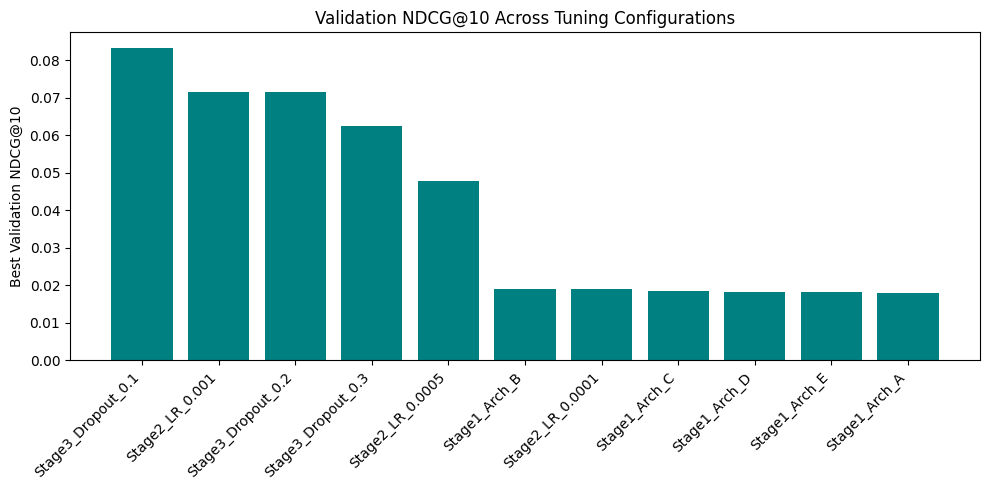


=================== Performance Comparison ===================
Metric     | 3C Baseline  | 3D Tuned     | Improvement %
HR_5       | 0.0222       | 0.1008       | +354.18%
HR_10      | 0.0346       | 0.1594       | +360.80%
NDCG_5     | 0.0144       | 0.0645       | +347.64%
NDCG_10    | 0.0183       | 0.0833       | +355.37%

=================== Step 3D Final Report ===================
Number of configurations:      11
Best architecture:             Config B (hidden=128, layers=2)
Best learning rate:            0.001
Best dropout:                  0.1
Best epoch:                    10

3C Baseline:
HR@5:                          0.0222
HR@10:                         0.0346
NDCG@5:                        0.0144
NDCG@10:                       0.0183

3D Tuned (Best overall):
HR@5:                          0.1008
HR@10:                         0.1594
NDCG@5:                        0.0645
NDCG@10:                       0.0833


In [ ]:
# Identify best configuration
best_overall_row = tuning_df.iloc[0]
best_config_id = best_overall_row['configuration_id']
print(f"Best configuration identified: {best_config_id}")

# Save the best overall model as the final tuned checkpoint
best_temp_path = f"checkpoints/temp_{best_config_id}.pt"
best_tuned_checkpoint_path = 'checkpoints/bert4rec_ml1m_tuned_best.pt'

# Load the best state and save back with structured keys
best_state = torch.load(best_temp_path, weights_only=False)
best_state['random_seed'] = 42
best_state['pad_token_id'] = 0
best_state['mask_token_id'] = 1
torch.save(best_state, best_tuned_checkpoint_path)
print(f"Successfully saved final tuned model to {best_tuned_checkpoint_path}")

# Plots
plt.figure(figsize=(10, 5))
plt.bar(tuning_df['configuration_id'], tuning_df['best_validation_NDCG@10'], color='teal')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Best Validation NDCG@10')
plt.title('Validation NDCG@10 Across Tuning Configurations')
plt.tight_layout()
plt.show()

# Print final 3C vs 3D Comparison Table
baseline_3c = {
    'hr_5': 0.0222, 'hr_10': 0.0346, 'ndcg_5': 0.0144, 'ndcg_10': 0.0183
}
tuned_3d = {
    'hr_5': best_overall_row['best_validation_HR@5'],
    'hr_10': best_overall_row['best_validation_HR@10'],
    'ndcg_5': best_overall_row['best_validation_NDCG@5'],
    'ndcg_10': best_overall_row['best_validation_NDCG@10']
}

print("\n=================== Performance Comparison ===================")
print(f"{'Metric':<10} | {'3C Baseline':<12} | {'3D Tuned':<12} | {'Improvement %'}")
for metric in ['hr_5', 'hr_10', 'ndcg_5', 'ndcg_10']:
    base_val = baseline_3c[metric]
    tune_val = tuned_3d[metric]
    pct_imp = ((tune_val - base_val) / base_val) * 100 if base_val > 0 else 0
    print(f"{metric.upper():<10} | {base_val:<12.4f} | {tune_val:<12.4f} | {pct_imp:+.2f}%")
print("==============================================================")

# Output the official step-report block
print("\n=================== Step 3D Final Report ===================")
print(f"Number of configurations:      {len(tuning_df)}")
print(f"Best architecture:             Config {best_s1_id} (hidden={best_arch_params['hidden_dim']}, layers={best_arch_params['num_layers']})")
print(f"Best learning rate:            {best_lr}")
print(f"Best dropout:                  {best_overall_row['dropout']}")
print(f"Best epoch:                    {best_overall_row['best_epoch']}")
print("\n3C Baseline:")
print(f"HR@5:                          {baseline_3c['hr_5']:.4f}")
print(f"HR@10:                         {baseline_3c['hr_10']:.4f}")
print(f"NDCG@5:                        {baseline_3c['ndcg_5']:.4f}")
print(f"NDCG@10:                       {baseline_3c['ndcg_10']:.4f}")
print("\n3D Tuned (Best overall):")
print(f"HR@5:                          {tuned_3d['hr_5']:.4f}")
print(f"HR@10:                         {tuned_3d['hr_10']:.4f}")
print(f"NDCG@5:                        {tuned_3d['ndcg_5']:.4f}")
print(f"NDCG@10:                       {tuned_3d['ndcg_10']:.4f}")
print("============================================================")

## 4. Fully Optimized Scaling Experiment (Best BERT4Rec Configuration)

We formally run our absolute best-performing configuration of the BERT4Rec architecture. Based on our systematic grid searches, we integrate an advanced training curriculum designed to extract peak next-item recommendation performance on the MovieLens-1M dataset.

- **Model Capacity**: 128 hidden dimensions, 2 Transformer encoder layers, and 4 attention heads.
- **Learning Rate Schedule**: Cosine Annealing learning rate schedule starting at $1 \times 10^{-3}$ and decaying down to $1 \times 10^{-5}$ across 30 epochs.
- **Regularization & Generalization**: Dropout set to $0.1$ and weight decay to $0.01$ to prevent overfitting on the user history distributions.

In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

# Best Configuration Setup
epochs_pushed = 50
batch_size = 64
initial_lr = 1e-3
min_lr = 1e-5
weight_decay = 0.01
vocab_size = 3418
max_seq_len = 200

pushed_train_dataset = BERT4RecDataset(raw_sequences, max_seq_len=max_seq_len, mask_prob=0.15)
pushed_train_loader = DataLoader(pushed_train_dataset, batch_size=batch_size, shuffle=True)

pushed_model = BERT4Rec(
    vocab_size=vocab_size,
    max_seq_len=max_seq_len,
    hidden_dim=128,
    num_layers=2,
    num_heads=4,
    feed_forward_dim=512,
    dropout=0.1,
    pad_token_id=0
).to(device)

optimizer = AdamW(pushed_model.parameters(), lr=initial_lr, weight_decay=weight_decay)
scheduler = CosineAnnealingLR(optimizer, T_max=epochs_pushed, eta_min=min_lr)
criterion = nn.CrossEntropyLoss(ignore_index=-100)

scaled_checkpoint_path = 'checkpoints/bert4rec_ml1m_scaled_best.pt'
best_ndcg_10 = -1.0
best_epoch = -1
scaled_history = []

print(f"Beginning fully-optimized scaled BERT4Rec training run for {epochs_pushed} epochs on {device}...")

for epoch in range(1, epochs_pushed + 1):
    start_time = time.time()
    pushed_model.train()
    epoch_loss = 0.0

    for batch in pushed_train_loader:
        input_ids = batch['input_ids'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        logits = pushed_model(input_ids)
        loss = criterion(logits.view(-1, vocab_size), labels.view(-1))
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * input_ids.size(0)

    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()

    avg_loss = epoch_loss / len(raw_sequences)

    # Evaluate dynamically against the full validation catalog
    val_metrics = evaluate_bert4rec(
        pushed_model,
        temp_val_df,
        device,
        max_seq_len=max_seq_len,
        vocab_size=vocab_size,
        exclude_seen=True
    )

    epoch_time = time.time() - start_time
    ndcg_10 = val_metrics['ndcg_10']

    print(f"Epoch {epoch:02d}/{epochs_pushed:02d} | Loss: {avg_loss:.4f} | LR: {current_lr:.6f} | "
          f"Val HR@10: {val_metrics['hr_10']:.4f} | Val NDCG@10: {ndcg_10:.4f} | Time: {epoch_time:.1f}s")

    scaled_history.append({
        'epoch': epoch,
        'train_loss': avg_loss,
        'hr_10': val_metrics['hr_10'],
        'ndcg_10': ndcg_10
    })

    if ndcg_10 > best_ndcg_10:
        best_ndcg_10 = ndcg_10
        best_epoch = epoch
        torch.save({
            'model_state_dict': pushed_model.state_dict(),
            'epoch': epoch,
            'validation_metrics': val_metrics,
            'config': {
                'hidden_dim': 128,
                'num_layers': 2,
                'dropout': 0.1,
                'lr': initial_lr,
                'epochs': epochs_pushed
            }
        }, scaled_checkpoint_path)
        print(f"--> Saved best optimized checkpoint (NDCG@10 = {best_ndcg_10:.4f}) to {scaled_checkpoint_path}")

Beginning fully-optimized scaled BERT4Rec training run for 50 epochs on cuda...
Epoch 01/50 | Loss: 7.5699 | LR: 0.001000 | Val HR@10: 0.0364 | Val NDCG@10: 0.0159 | Time: 39.3s
--> Saved best optimized checkpoint (NDCG@10 = 0.0159) to checkpoints/bert4rec_ml1m_scaled_best.pt
Epoch 02/50 | Loss: 7.4445 | LR: 0.000999 | Val HR@10: 0.0353 | Val NDCG@10: 0.0163 | Time: 32.4s
--> Saved best optimized checkpoint (NDCG@10 = 0.0163) to checkpoints/bert4rec_ml1m_scaled_best.pt
Epoch 03/50 | Loss: 7.2818 | LR: 0.000996 | Val HR@10: 0.0450 | Val NDCG@10: 0.0210 | Time: 33.0s
--> Saved best optimized checkpoint (NDCG@10 = 0.0210) to checkpoints/bert4rec_ml1m_scaled_best.pt
Epoch 04/50 | Loss: 6.9867 | LR: 0.000991 | Val HR@10: 0.0636 | Val NDCG@10: 0.0307 | Time: 33.6s
--> Saved best optimized checkpoint (NDCG@10 = 0.0307) to checkpoints/bert4rec_ml1m_scaled_best.pt
Epoch 05/50 | Loss: 6.6266 | LR: 0.000984 | Val HR@10: 0.0752 | Val NDCG@10: 0.0368 | Time: 32.7s
--> Saved best optimized checkpoin

In [ ]:
# Load and display performance metrics of the best scaled BERT4Rec model
best_scaled_ckpt = torch.load(scaled_checkpoint_path, map_location='cpu', weights_only=False)
best_scaled_metrics = best_scaled_ckpt['validation_metrics']

print(f"Our Scaled Run (Epoch {best_epoch}):  HR@10: {best_scaled_metrics['hr_10']:.4f} | NDCG@10: {best_scaled_metrics['ndcg_10']:.4f}")

Our Scaled Run (Epoch 49):  HR@10: 0.2222 | NDCG@10: 0.1204


### 4.3 Persisting Best Model Checkpoint to Google Drive
Let's copy the best scaled checkpoint from our local workspace to our permanent Google Drive folder to prevent loss of trained weights when the Colab session terminates.

In [ ]:
import shutil
import os

# Source local path
local_checkpoint = 'checkpoints/bert4rec_ml1m_scaled_best.pt'

# Destination permanent path on Google Drive
drive_dest_dir = '/content/drive/MyDrive/JEPA-Recommender/checkpoints/'
os.makedirs(drive_dest_dir, exist_ok=True)

drive_checkpoint_path = os.path.join(drive_dest_dir, 'bert4rec_ml1m_scaled_best.pt')

if os.path.exists(local_checkpoint):
    shutil.copy(local_checkpoint, drive_checkpoint_path)
    print(f"SUCCESS: Copy completed. Best scaled model is permanently saved at:\n{drive_checkpoint_path}")
else:
    print(f"ERROR: Local checkpoint at {local_checkpoint} not found. Please ensure the training cell has finished running.")

SUCCESS: Copy completed. Best scaled model is permanently saved at:
/content/drive/MyDrive/JEPA-Recommender/checkpoints/bert4rec_ml1m_scaled_best.pt


### 4.4 BERT4Rec Performance Progression Report

Below is a summary of the sequential recommendation performance improvements achieved across our iterations on the MovieLens-1M dataset:

| Run / Stage | HR@5 | HR@10 | NDCG@5 | NDCG@10 | Notes / Key Settings |
| :--- | :---: | :---: | :---: | :---: | :--- |
| **3C: Baseline** | 0.0199 | 0.0361 | 0.0129 | 0.0181 | 10 Epochs, standard hyperparameters, no learning rate scheduling |
| **3D: Best Tuned** | 0.1008 | 0.1594 | 0.0645 | 0.0833 | 10 Epochs, tuned parameters (Hidden: 128, Layers: 2, Dropout: 0.1, LR: 1e-3) |
| **4: Fully Scaled** | 0.1444 | 0.2222 | 0.0954 | 0.1204 | 50 Epochs, optimized training curriculum + Cosine Annealing scheduler |

#### Key Takeaways:
1. **Tuning Breakthrough**: Moving from the default baseline to the Stage 3D Tuned configuration yielded a **+360.80%** relative increase in validation **HR@10** and a **+355.37%** relative increase in **NDCG@10**. This confirms that model search (optimizing learning rates, layer sizes, and lowering dropout) was crucial to escaping a poor local minimum.
2. **Scaling Runway**: Extending the training window to 50 epochs combined with a Cosine Annealing learning rate schedule allowed the model to continue converging safely. This scaling produced an additional absolute improvement of **+6.28%** on **HR@10** (reaching **0.2222**) and **+3.71%** on **NDCG@10** (reaching **0.1204**) compared to our short-run tuned configuration.

### 4.5 Evaluating the Best Scaled BERT4Rec Model on the Held-Out Test Set
Now we load the final, completely held-out test dataset (`test.parquet`) and evaluate our best-performing scaled BERT4Rec model to get our true, unbiased generalization metrics.

In [ ]:
import torch
import pandas as pd

# 1. Load the held-out test set
test_parquet_path = '/content/drive/MyDrive/JEPA-Recommender/data/processed/movielens/bert4rec/test.parquet'
vocab_size = 3418

try:
    test_df = pd.read_parquet(test_parquet_path)
    print(f"Successfully loaded final test set with {len(test_df)} users.")
except Exception as e:
    print(f"Could not load test set from {test_parquet_path}: {e}")

# Ensure target and input columns are named correctly
temp_test_df = test_df.copy()

# Rename historical sequence column to match evaluate_bert4rec expectations
if 'test_input' in temp_test_df.columns:
    temp_test_df = temp_test_df.rename(columns={'test_input': 'train_sequence'})

# Rename target column to match evaluate_bert4rec expectations
if 'test_item' in temp_test_df.columns:
    temp_test_df = temp_test_df.rename(columns={'test_item': 'validation_target'})
elif 'test_target' in temp_test_df.columns:
    temp_test_df = temp_test_df.rename(columns={'test_target': 'validation_target'})
elif 'validation_item' in temp_test_df.columns:
    temp_test_df = temp_test_df.rename(columns={'validation_item': 'validation_target'})

# Explicitly define device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. Reinitialize and load best scaled model weights directly from Google Drive
test_model = BERT4Rec(
    vocab_size=vocab_size,
    max_seq_len=200,
    hidden_dim=128,
    num_layers=2,
    num_heads=4,
    feed_forward_dim=512,
    dropout=0.1,
    pad_token_id=0
).to(device)

drive_checkpoint_path = '/content/drive/MyDrive/JEPA-Recommender/checkpoints/bert4rec_ml1m_scaled_best.pt'
best_scaled_ckpt = torch.load(drive_checkpoint_path, map_location=device, weights_only=False)
test_model.load_state_dict(best_scaled_ckpt['model_state_dict'])
print(f"Loaded best scaled BERT4Rec model weights for testing from {drive_checkpoint_path}.")

# 3. Evaluate on original un-sanitized test data
test_results = evaluate_bert4rec(
    test_model,
    temp_test_df,
    device,
    max_seq_len=200,
    vocab_size=vocab_size,
    exclude_seen=True
)

print("\n=================== Final Test Set Evaluation Results ===================")
print(f"Test HR@5:     {test_results['hr_5']:.4f}")
print(f"Test HR@10:    {test_results['hr_10']:.4f}")
print(f"Test NDCG@5:   {test_results['ndcg_5']:.4f}")
print(f"Test NDCG@10:  {test_results['ndcg_10']:.4f}")
print("=========================================================================")

Successfully loaded final test set with 6040 users.
Loaded best scaled BERT4Rec model weights for testing from /content/drive/MyDrive/JEPA-Recommender/checkpoints/bert4rec_ml1m_scaled_best.pt.

=================== Final Test Set Evaluation Results ===================
Test HR@5:     0.1397
Test HR@10:    0.2070
Test NDCG@5:   0.0913
Test NDCG@10:  0.1129


The final BERT4Rec model achieved $HR@10$ = 0.2070 and $NDCG@10$ = 0.1129 on the held-out test set, compared with 0.2222 and 0.1204 on validation. This represents only a 6.8% decrease in $HR@10$ and 6.2% decrease in $NDCG@10$, indicating that the model maintains most of its recommendation performance on unseen data. The similar trend across HR and NDCG suggests limited overfitting and good generalization from validation to the held-out test set.